In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df = pd.read_csv("data/home-credit-default-risk/application_train.csv")
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [59]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [60]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [61]:
df.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [62]:
print("percent of the column TARGET varilable (availability)")
df['TARGET'].value_counts(normalize=True) #highly imbalance

percent of the column TARGET varilable (availability)


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [63]:
missing_df = df.isnull().mean().sort_values(ascending=False)
missing_df

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
                              ...   
FLAG_DOCUMENT_16            0.000000
FLAG_DOCUMENT_15            0.000000
FLAG_DOCUMENT_14            0.000000
FLAG_DOCUMENT_20            0.000000
FLAG_DOCUMENT_21            0.000000
Length: 122, dtype: float64

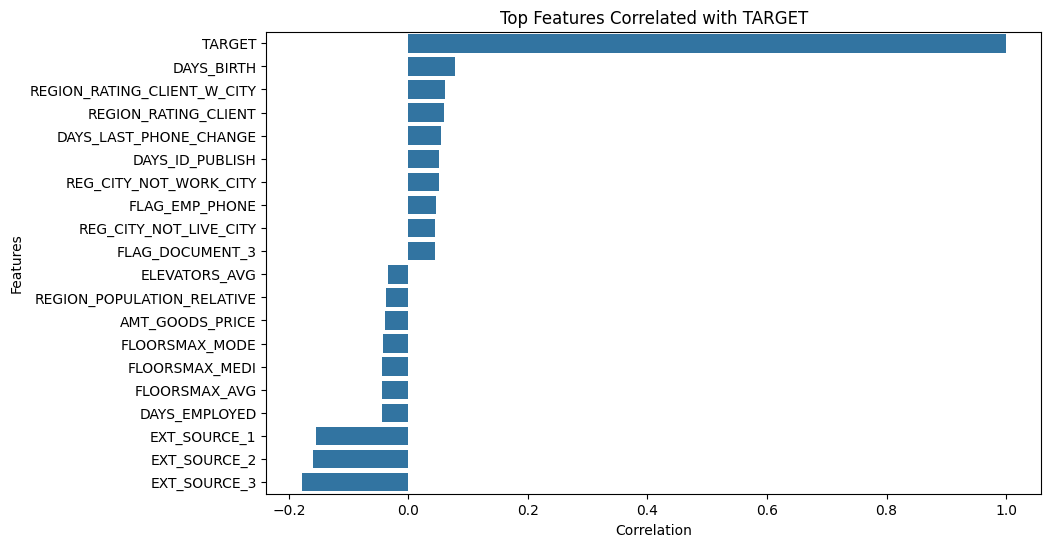

Top Positive Correlations:
 TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
Name: TARGET, dtype: float64

Top Negative Correlations:
 FLAG_DOCUMENT_5             -0.000316
FLAG_DOCUMENT_12            -0.000756
FLAG_DOCUMENT_19            -0.001358
FLAG_DOCUMENT_10            -0.001414
FLAG_DOCUMENT_7             -0.001520
NONLIVINGAPARTMENTS_MODE    -0.001557
FLAG_EMAIL                  -0.001758
AMT_REQ_CREDIT_BUREAU_QRT   -0.002022
SK_ID_CURR                  -0.002108
FLAG_DOCUMENT_4             -0.002672
Name: TARGET, dtype: float64


In [64]:
# Select only numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])
# Compute correlation with TARGET
target_corr = num_df.corr()['TARGET'].sort_values(ascending=False)

# Display
target_corr.head(20)
import matplotlib.pyplot as plt
import seaborn as sns

# Top positive and negative correlations
top_pos = target_corr.head(10)
top_neg = target_corr.tail(10)

top_corr = pd.concat([top_pos, top_neg])

plt.figure(figsize=(10,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top Features Correlated with TARGET")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()
# Positive correlation (risk increasing)
positive_corr = target_corr[target_corr > 0]

# Negative correlation (risk decreasing)
negative_corr = target_corr[target_corr < 0]

print("Top Positive Correlations:\n", positive_corr.head(10))
print("\nTop Negative Correlations:\n", negative_corr.head(10))

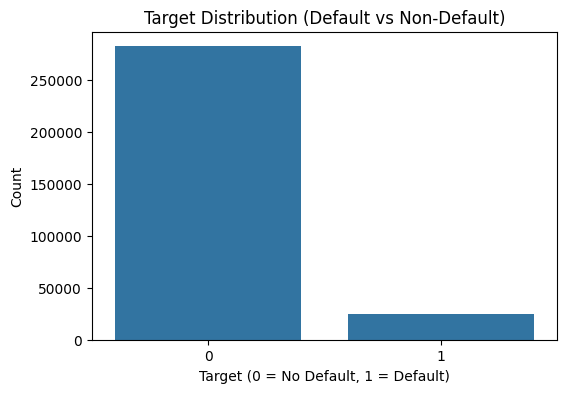

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=df)

plt.title("Target Distribution (Default vs Non-Default)")
plt.xlabel("Target (0 = No Default, 1 = Default)")
plt.ylabel("Count")

plt.show()

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Get missing % for every column
missing = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum().values,
    'missing_pct': (df.isnull().mean() * 100).values,
    'dtype': df.dtypes.values
}).sort_values('missing_pct', ascending=False)

print(missing[missing['missing_pct'] > 0].shape[0], "columns have missing values")
missing[missing['missing_pct'] > 0].head(30)

67 columns have missing values


,column,missing_count,missing_pct,dtype
48,COMMONAREA_AVG,214865,69.872297,float64
62,COMMONAREA_MODE,214865,69.872297,float64
76,COMMONAREA_MEDI,214865,69.872297,float64
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963,float64
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963,float64
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963,float64
86,FONDKAPREMONT_MODE,210295,68.386172,object
54,LIVINGAPARTMENTS_AVG,210199,68.354953,float64
82,LIVINGAPARTMENTS_MEDI,210199,68.354953,float64
68,LIVINGAPARTMENTS_MODE,210199,68.354953,float64


In [69]:
# Identify and drop columns with >60% missing
threshold = 60.0
cols_to_drop = missing[missing['missing_pct'] > threshold]['column'].tolist()

print(f"Dropping {len(cols_to_drop)} columns with >60% missing:")
print(cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)

Dropping 17 columns with >60% missing:
['COMMONAREA_AVG', 'COMMONAREA_MODE', 'COMMONAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'OWN_CAR_AGE']


In [70]:
# Override: always keep EXT_SOURCE columns despite high missingness
ALWAYS_KEEP = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
cols_to_drop = [c for c in cols_to_drop if c not in ALWAYS_KEEP]

In [71]:
tier2_cols = missing[
    (missing['missing_pct'] >= 30) & (missing['missing_pct'] < 60)
]['column'].tolist()

for col in tier2_cols:
    # Create binary indicator: 1 = was missing, 0 = was present
    df[f'{col}_MISSING'] = df[col].isnull().astype(int)

# Then impute the original column
# Numeric → median
# Categorical → 'Unknown'

num_tier2 = [c for c in tier2_cols if df[c].dtype in ['float64', 'int64']]
cat_tier2 = [c for c in tier2_cols if df[c].dtype == 'object']

for col in num_tier2:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_tier2:
    df[col].fillna('Unknown', inplace=True)

C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\3747966343.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\3747966343.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [72]:
# ── AMT_ANNUITY (missing ~0.05%) ──
# Loan annuity — can be estimated from credit amount and term
# Simple approach: use median by loan type
df['AMT_ANNUITY'] = df.groupby('NAME_CONTRACT_TYPE')['AMT_ANNUITY'] \
                        .transform(lambda x: x.fillna(x.median()))

# ── AMT_GOODS_PRICE (missing ~0.1%) ──
# Goods price — fill with credit amount as proxy
df['AMT_GOODS_PRICE'] = df['AMT_GOODS_PRICE'].fillna(df['AMT_CREDIT'])

# ── CNT_FAM_MEMBERS (missing ~0.01%) ──
# Family members — fill with 1 (single person assumption)
df['CNT_FAM_MEMBERS'] = df['CNT_FAM_MEMBERS'].fillna(1)

# ── EXT_SOURCE_1, 2, 3 ──
# These are external credit bureau scores — very predictive
# Strategy: use median grouped by occupation and education
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    df[col] = df.groupby(['NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE'])[col] \
                  .transform(lambda x: x.fillna(x.median()))
    # Fallback: if group median is also NaN, use global median
    df[col] = df[col].fillna(df[col].median())

C:\Users\SHUBHAM\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [75]:
!pip install scikit-learn
from sklearn.impute import SimpleImputer

# All remaining numeric columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Numeric → median (robust to outliers)
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical → most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.0 MB 5.5 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.0 MB 6.4 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.0 MB 6.0 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.0 MB 5.8 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.0 MB 4.9 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 4.6 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 4.6 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.0 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 4.3 MB/s  0:00:01
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    --------------------------------------- 0.5/36.5 MB 2.8 MB/s eta 0:00:13
   - --------------------

In [77]:
bureau_df = pd.read_csv("data/bureau.csv")
bureau_df.shape

(1716428, 17)

In [81]:
df.isnull().sum()
# AMT_CREDIT_SUM_DEBT → fill with 0 (no debt recorded = assume zero)
bureau_df['AMT_CREDIT_SUM_DEBT'].fillna(0, inplace=True)

# AMT_CREDIT_MAX_OVERDUE → fill with 0 (no overdue recorded)
bureau_df['AMT_CREDIT_MAX_OVERDUE'].fillna(0, inplace=True)

# AMT_CREDIT_SUM_LIMIT → fill with 0
bureau_df['AMT_CREDIT_SUM_LIMIT'].fillna(0, inplace=True)

# DAYS_CREDIT_ENDDATE → fill with median
bureau_df['DAYS_CREDIT_ENDDATE'].fillna(bureau_df['DAYS_CREDIT_ENDDATE'].median(), inplace=True)

C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\4080325481.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bureau_df['AMT_CREDIT_SUM_DEBT'].fillna(0, inplace=True)
C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\4080325481.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [83]:
inst = pd.read_csv('data/installments_payments.csv')

# AMT_PAYMENT missing → payment was likely missed, fill with 0
inst['AMT_PAYMENT'].fillna(0, inplace=True)

# DAYS_ENTRY_PAYMENT missing → derive a payment delay feature
inst['PAYMENT_DIFF'] = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
inst['PAYMENT_DIFF'].fillna(inst['PAYMENT_DIFF'].median(), inplace=True)

C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\1709525631.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inst['AMT_PAYMENT'].fillna(0, inplace=True)
C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\1709525631.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [84]:
prev = pd.read_csv('data/previous_application.csv')

# AMT_DOWN_PAYMENT → fill with 0 (no down payment)
prev['AMT_DOWN_PAYMENT'].fillna(0, inplace=True)

# RATE_DOWN_PAYMENT → fill with 0
prev['RATE_DOWN_PAYMENT'].fillna(0, inplace=True)

# DAYS_LAST_DUE, DAYS_TERMINATION → fill with median
for col in ['DAYS_LAST_DUE', 'DAYS_TERMINATION', 'DAYS_FIRST_DRAWING']:
    prev[col] = prev[col].replace(365243, np.nan)
    prev[col].fillna(prev[col].median(), inplace=True)

C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\4168915058.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  prev['AMT_DOWN_PAYMENT'].fillna(0, inplace=True)
C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\4168915058.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

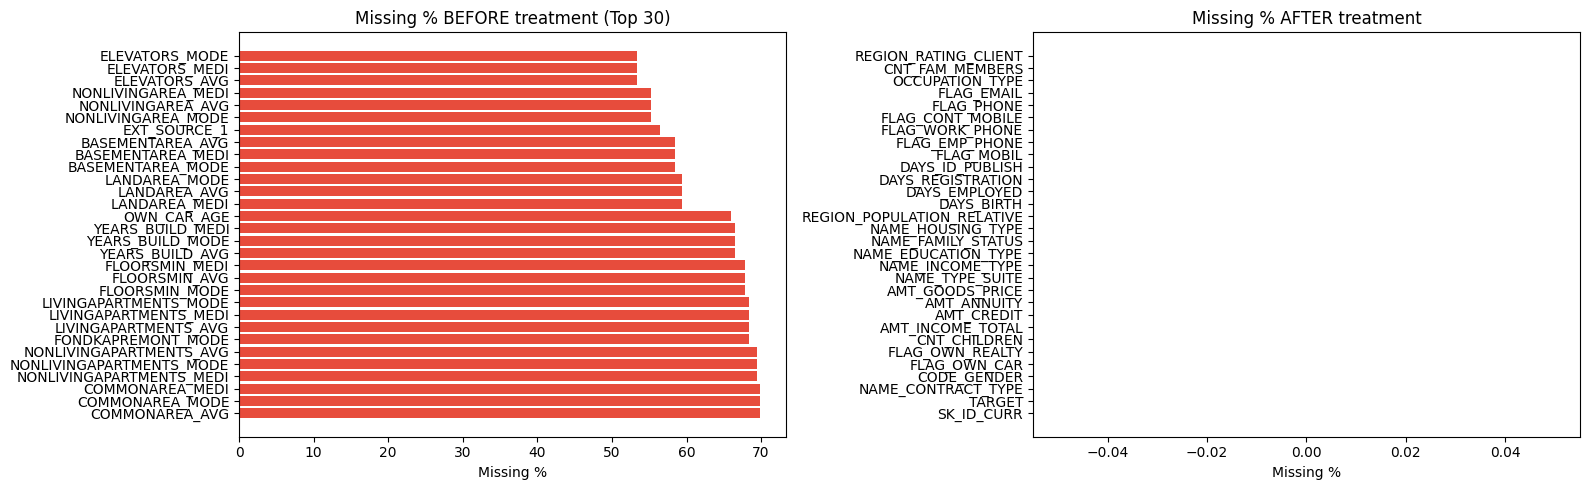

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before
miss_before = missing[missing['missing_pct'] > 0].head(30)
axes[0].barh(miss_before['column'], miss_before['missing_pct'], color='#e74c3c')
axes[0].set_title('Missing % BEFORE treatment (Top 30)')
axes[0].set_xlabel('Missing %')

# After
miss_after = (df.isnull().mean() * 100).sort_values(ascending=False).head(30)
axes[1].barh(miss_after.index, miss_after.values, color='#2ecc71')
axes[1].set_title('Missing % AFTER treatment')
axes[1].set_xlabel('Missing %')

plt.tight_layout()
plt.show()

In [88]:
#encoding
# Get full picture of all categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

audit = pd.DataFrame({
    'column'      : cat_cols,
    'unique_vals' : [df[col].nunique() for col in cat_cols],
    'missing_pct' : [df[col].isnull().mean()*100 for col in cat_cols],
    'top_value'   : [df[col].mode()[0] for col in cat_cols],
    'top_freq_pct': [df[col].value_counts(normalize=True).iloc[0]*100 
                     for col in cat_cols]
}).sort_values('unique_vals')

print(audit.to_string(index=False))

                    column  unique_vals  missing_pct                     top_value  top_freq_pct
        NAME_CONTRACT_TYPE            2          0.0                    Cash loans     90.478715
              FLAG_OWN_CAR            2          0.0                             N     65.989184
           FLAG_OWN_REALTY            2          0.0                             Y     69.367275
               CODE_GENDER            3          0.0                             F     65.834393
       EMERGENCYSTATE_MODE            3          0.0                            No     51.844649
            HOUSETYPE_MODE            4          0.0                       Unknown     50.176091
       NAME_EDUCATION_TYPE            5          0.0 Secondary / secondary special     71.018923
        NAME_FAMILY_STATUS            6          0.0                       Married     63.878040
         NAME_HOUSING_TYPE            6          0.0             House / apartment     88.734387
           NAME_TYPE_SUITE    

In [89]:
# These 4 columns have exactly 2 values
# Use explicit maps — never rely on alphabetical LabelEncoder ordering

binary_mappings = {
    'FLAG_OWN_CAR'        : {'Y': 1, 'N': 0},
    'FLAG_OWN_REALTY'     : {'Y': 1, 'N': 0},
    'NAME_CONTRACT_TYPE'  : {'Cash loans': 1, 'Revolving loans': 0},
    'EMERGENCYSTATE_MODE' : {'Yes': 1, 'No': 0}
}

for col, mapping in binary_mappings.items():
    df[col] = df[col].map(mapping)
    print(f"✅ {col}: {df[col].value_counts().to_dict()}")

✅ FLAG_OWN_CAR: {0: 202924, 1: 104587}
✅ FLAG_OWN_REALTY: {1: 213312, 0: 94199}
✅ NAME_CONTRACT_TYPE: {1: 278232, 0: 29279}
✅ EMERGENCYSTATE_MODE: {0.0: 159428, 1.0: 2328}


In [91]:
# Sanity check — default rate should differ between 0 and 1
for col in binary_mappings.keys():
    rate = df.groupby(col)['TARGET'].mean()
    print(f"\n{col} default rates:\n{rate}")


FLAG_OWN_CAR default rates:
FLAG_OWN_CAR
0    0.085002
1    0.072437
Name: TARGET, dtype: float64

FLAG_OWN_REALTY default rates:
FLAG_OWN_REALTY
0    0.083249
1    0.079616
Name: TARGET, dtype: float64

NAME_CONTRACT_TYPE default rates:
NAME_CONTRACT_TYPE
0    0.054783
1    0.083459
Name: TARGET, dtype: float64

EMERGENCYSTATE_MODE default rates:
EMERGENCYSTATE_MODE
0.0    0.069649
1.0    0.095790
Name: TARGET, dtype: float64


In [92]:
# NAME_EDUCATION_TYPE has a clear real-world hierarchy
# Higher number = more education = typically lower default risk

print("Current default rates by education:")
print(df.groupby('NAME_EDUCATION_TYPE')['TARGET']
      .mean().sort_values(ascending=False))

education_order = {
    'Lower secondary'               : 1,
    'Secondary / secondary special' : 2,
    'Incomplete higher'             : 3,
    'Higher education'              : 4,
    'Academic degree'               : 5
}

df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map(education_order)

# Confirm monotonic relationship with default rate
print("\nAfter encoding — default rate per level:")
print(df.groupby('NAME_EDUCATION_TYPE')['TARGET']
      .mean().sort_index())
# Should decrease as level increases

Current default rates by education:
NAME_EDUCATION_TYPE
Lower secondary                  0.109277
Secondary / secondary special    0.089399
Incomplete higher                0.084850
Higher education                 0.053551
Academic degree                  0.018293
Name: TARGET, dtype: float64

After encoding — default rate per level:
NAME_EDUCATION_TYPE
1    0.109277
2    0.089399
3    0.084850
4    0.053551
5    0.018293
Name: TARGET, dtype: float64


In [94]:
def group_rare_categories(df, col, threshold=0.01):
    """
    Replace categories appearing in less than threshold% of rows with 'Other'
    """

    # ✅ Check if column exists
    if col not in df.columns:
        print(f"⚠️ Skipping {col} (column not found)")
        return df

    # ✅ Calculate frequency
    freq = df[col].value_counts(normalize=True)

    # ✅ Identify rare categories
    rare_cats = freq[freq < threshold].index.tolist()

    if rare_cats:
        print(f"  {col}: grouping {len(rare_cats)} rare categories → 'Other'")
        print(f"  Rare: {rare_cats}")

        # ✅ Proper assignment (no inplace warning)
        df[col] = df[col].replace(rare_cats, 'Other')

    return df


# ✅ Original candidate list
ohe_candidates = [
    'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 
    'WALLSMATERIAL_MODE'
]

# ✅ Keep only columns that exist (VERY IMPORTANT)
ohe_candidates = [col for col in ohe_candidates if col in df.columns]

print("Columns being processed:", ohe_candidates)

# ✅ Apply function
for col in ohe_candidates:
    df = group_rare_categories(df, col, threshold=0.01)

print("\n✅ Rare category grouping complete")
print("Updated unique counts:")

# ✅ Safe printing
for col in ohe_candidates:
    print(f"  {col}: {df[col].nunique()} categories")

Columns being processed: ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']
  NAME_TYPE_SUITE: grouping 1 rare categories → 'Other'
  Rare: ['Other']
  NAME_INCOME_TYPE: grouping 1 rare categories → 'Other'
  Rare: ['Other']
  NAME_FAMILY_STATUS: grouping 1 rare categories → 'Other'
  Rare: ['Other']
  HOUSETYPE_MODE: grouping 2 rare categories → 'Other'
  Rare: ['specific housing', 'terraced house']
  WALLSMATERIAL_MODE: grouping 3 rare categories → 'Other'
  Rare: ['Mixed', 'Monolithic', 'Others']

✅ Rare category grouping complete
Updated unique counts:
  NAME_TYPE_SUITE: 5 categories
  NAME_INCOME_TYPE: 5 categories
  NAME_FAMILY_STATUS: 6 categories
  NAME_HOUSING_TYPE: 5 categories
  HOUSETYPE_MODE: 3 categories
  WALLSMATERIAL_MODE: 6 categories


In [95]:
# Fill missing before OHE so 'Unknown' becomes its own category
# (already done in missing value step but double check)
for col in ohe_candidates:
    df[col] = df[col].fillna('Unknown')

cols_before = df.shape[1]

# drop_first=True prevents multicollinearity for Logistic Regression
df = pd.get_dummies(
    df, 
    columns=ohe_candidates, 
    drop_first=True, 
    dtype=int
)

cols_after = df.shape[1]
print(f"Columns added by OHE: {cols_after - cols_before}")
print(f"Shape after OHE: {df.shape}")

# Verify — check sample of new columns
ohe_new_cols = [c for c in df.columns if any(
    c.startswith(base) for base in ohe_candidates
)]
print(f"\nNew OHE columns created: {len(ohe_new_cols)}")
print(ohe_new_cols[:10])

Columns added by OHE: 18
Shape after OHE: (307511, 156)

New OHE columns created: 26
['WALLSMATERIAL_MODE_MISSING', 'HOUSETYPE_MODE_MISSING', 'NAME_TYPE_SUITE_Family', 'NAME_TYPE_SUITE_Other', 'NAME_TYPE_SUITE_Spouse, partner', 'NAME_TYPE_SUITE_Unaccompanied', 'NAME_INCOME_TYPE_Other', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Working']


In [96]:
# WEEKDAY_APPR_PROCESS_START is cyclical
# Monday and Sunday are adjacent — OHE loses this relationship
# Sin/Cos encoding preserves the circular structure

print("Default rate by weekday:")
print(df.groupby('WEEKDAY_APPR_PROCESS_START')['TARGET']
      .mean().sort_values(ascending=False))

weekday_map = {
    'MONDAY': 0, 'TUESDAY': 1, 'WEDNESDAY': 2,
    'THURSDAY': 3, 'FRIDAY': 4, 'SATURDAY': 5, 'SUNDAY': 6
}

df['WEEKDAY_NUM'] = df['WEEKDAY_APPR_PROCESS_START'].map(weekday_map)

# Sin and Cos components
df['WEEKDAY_SIN'] = np.sin(2 * np.pi * df['WEEKDAY_NUM'] / 7)
df['WEEKDAY_COS'] = np.cos(2 * np.pi * df['WEEKDAY_NUM'] / 7)

# Drop intermediary and original
df.drop(columns=['WEEKDAY_APPR_PROCESS_START', 'WEEKDAY_NUM'], inplace=True)

print("✅ Cyclical encoding applied → WEEKDAY_SIN, WEEKDAY_COS created")

Default rate by weekday:
WEEKDAY_APPR_PROCESS_START
TUESDAY      0.083505
WEDNESDAY    0.081604
FRIDAY       0.081469
THURSDAY     0.081003
SUNDAY       0.079291
SATURDAY     0.078873
MONDAY       0.077572
Name: TARGET, dtype: float64
✅ Cyclical encoding applied → WEEKDAY_SIN, WEEKDAY_COS created


In [97]:
# OCCUPATION_TYPE (18) and ORGANIZATION_TYPE (58)
# Too many categories for OHE — creates too many sparse columns

high_card_cols = ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

for col in high_card_cols:
    # Frequency = proportion of times this category appears
    freq_map = df[col].value_counts(normalize=True).to_dict()
    df[f'{col}_FREQ'] = df[col].map(freq_map)
    
    print(f"\n{col} frequency encoding sample:")
    sample = df[[col, f'{col}_FREQ']].drop_duplicates() \
               .sort_values(f'{col}_FREQ', ascending=False).head(5)
    print(sample.to_string(index=False))


OCCUPATION_TYPE frequency encoding sample:
OCCUPATION_TYPE  OCCUPATION_TYPE_FREQ
        Unknown              0.313455
       Laborers              0.179460
    Sales staff              0.104393
     Core staff              0.089655
       Managers              0.069497

ORGANIZATION_TYPE frequency encoding sample:
     ORGANIZATION_TYPE  ORGANIZATION_TYPE_FREQ
Business Entity Type 3                0.221104
                   XNA                0.180072
         Self-employed                0.124913
                 Other                0.054252
              Medicine                0.036399


In [100]:
# MUST be done AFTER train/test split to prevent data leakage
# Split first, then apply target encoding

from sklearn.model_selection import train_test_split

X = df.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

# Now apply target encoding using TRAIN data only
train_temp = X_train.copy()
train_temp['TARGET'] = y_train.values

global_mean = y_train.mean()  # overall default rate ~0.08

for col in high_card_cols:
    
    # Compute mean default rate per category ON TRAIN ONLY
    target_map = train_temp.groupby(col)['TARGET'].mean().to_dict()
    
    # Apply to train
    X_train[f'{col}_TARGET_ENC'] = X_train[col].map(target_map)
    X_train[f'{col}_TARGET_ENC'].fillna(global_mean, inplace=True)
    
    # Apply same map to val (never recompute on val)
    X_val[f'{col}_TARGET_ENC'] = X_val[col].map(target_map)
    X_val[f'{col}_TARGET_ENC'].fillna(global_mean, inplace=True)

    print(f"\nTop defaulting {col}:")
    print(pd.Series(target_map).sort_values(ascending=False).head(5))
    print(f"Lowest defaulting {col}:")
    print(pd.Series(target_map).sort_values().head(5))


Top defaulting OCCUPATION_TYPE:
Low-skill Laborers      0.181014
Waiters/barmen staff    0.114723
Drivers                 0.112620
Security staff          0.106850
Laborers                0.105222
dtype: float64
Lowest defaulting OCCUPATION_TYPE:
Accountants              0.046308
IT staff                 0.061321
Managers                 0.062237
High skill tech staff    0.062796
Core staff               0.063821
dtype: float64

Top defaulting ORGANIZATION_TYPE:
Industry: type 8     0.157895
Transport: type 3    0.157676
Industry: type 13    0.137255
Construction         0.119467
Restaurant           0.116505
dtype: float64
Lowest defaulting ORGANIZATION_TYPE:
Trade: type 5        0.025000
Trade: type 4        0.038462
Trade: type 6        0.040650
Industry: type 12    0.040956
Military             0.049219
dtype: float64


C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\3378729511.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[f'{col}_TARGET_ENC'].fillna(global_mean, inplace=True)
C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\3378729511.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [101]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# ── STEP 1: All safe row-wise feature engineering on full df ──
# (pure math operations — no statistics from the data)

# Time conversions
df['AGE_YEARS']               = df['DAYS_BIRTH'].abs() / 365
df['YEARS_EMPLOYED']          = df['DAYS_EMPLOYED'].abs() / 365
df['YEARS_REGISTRATION']      = df['DAYS_REGISTRATION'].abs() / 365
df['YEARS_ID_PUBLISH']        = df['DAYS_ID_PUBLISH'].abs() / 365
df['YEARS_LAST_PHONE_CHANGE'] = df['DAYS_LAST_PHONE_CHANGE'].abs() / 365

days_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
             'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']
df.drop(columns=days_cols, inplace=True)

# Financial ratios
df['CREDIT_INCOME_RATIO']   = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO']  = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_GOODS_RATIO']    = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
df['INCOME_PER_PERSON']     = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
df['LOAN_TERM_MONTHS']      = df['AMT_CREDIT'] / df['AMT_ANNUITY']
df['ANNUITY_CREDIT_RATIO']  = df['AMT_ANNUITY'] / df['AMT_CREDIT']

# Employment features
df['EMPLOYMENT_AGE_RATIO']      = df['YEARS_EMPLOYED'] / df['AGE_YEARS']
df['AGE_AT_EMPLOYMENT_START']   = df['AGE_YEARS'] - df['YEARS_EMPLOYED']
df['REGISTRATION_TO_AGE_RATIO'] = df['YEARS_REGISTRATION'] / df['AGE_YEARS']

# External score combinations (row-wise — safe)
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
df['EXT_SOURCE_MEAN']     = df[ext_cols].mean(axis=1)
df['EXT_SOURCE_MIN']      = df[ext_cols].min(axis=1)
df['EXT_SOURCE_MAX']      = df[ext_cols].max(axis=1)
df['EXT_SOURCE_STD']      = df[ext_cols].std(axis=1)
df['EXT_SOURCE_WEIGHTED'] = (0.25*df['EXT_SOURCE_1'] +
                              0.50*df['EXT_SOURCE_2'] +
                              0.25*df['EXT_SOURCE_3'])
df['EXT_SOURCE_COUNT']    = df[ext_cols].notna().sum(axis=1)

# Document and contact flags
doc_cols     = [c for c in df.columns if c.startswith('FLAG_DOCUMENT_')]
contact_cols = [c for c in ['FLAG_MOBIL','FLAG_EMP_PHONE','FLAG_WORK_PHONE',
                              'FLAG_CONT_MOBILE','FLAG_PHONE','FLAG_EMAIL']
                if c in df.columns]

df['TOTAL_DOCUMENTS']       = df[doc_cols].sum(axis=1)
df['TOTAL_CONTACT_METHODS'] = df[contact_cols].sum(axis=1)

# Enquiry features
enquiry_cols = [c for c in df.columns if 'AMT_REQ_CREDIT_BUREAU' in c]
df['TOTAL_ENQUIRIES'] = df[enquiry_cols].sum(axis=1)

# Interaction terms (row-wise — safe)
df['AGE_x_EXT_SOURCE2']          = df['AGE_YEARS'] * df['EXT_SOURCE_2']
df['INCOME_x_EXT_SOURCE2']       = df['AMT_INCOME_TOTAL'] * df['EXT_SOURCE_2']
df['CREDIT_RATIO_x_EXT_SOURCE2'] = df['CREDIT_INCOME_RATIO'] * df['EXT_SOURCE_2']
df['EMPLOYMENT_x_INCOME']        = df['EMPLOYMENT_AGE_RATIO'] * df['AMT_INCOME_TOTAL']
df['ANNUITY_STRESS']             = df['ANNUITY_INCOME_RATIO'] * df['CNT_FAM_MEMBERS']

# Fix any inf values from division
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print(f"✅ Row-wise feature engineering done on full df")
print(f"df shape: {df.shape}")

✅ Row-wise feature engineering done on full df
df shape: (307511, 182)


In [ ]:
# ── STEP 3: Statistics-based features — AFTER split, on train only ──

# AGE BINNING — uses data distribution, must fit on train only
age_bins = pd.qcut(X_train['AGE_YEARS'], q=5, retbins=True)[1]  # get bin edges
X_train['AGE_GROUP'] = pd.cut(X_train['AGE_YEARS'], bins=age_bins,
                               labels=[0,1,2,3,4],
                               include_lowest=True).astype(int)
X_val['AGE_GROUP']   = pd.cut(X_val['AGE_YEARS'], bins=age_bins,
                               labels=[0,1,2,3,4],
                               include_lowest=True).astype(int)

# INCOME BINNING — same logic
income_bins = pd.qcut(X_train['AMT_INCOME_TOTAL'], q=5, retbins=True)[1]
X_train['INCOME_BRACKET'] = pd.cut(X_train['AMT_INCOME_TOTAL'],
                                    bins=income_bins,
                                    labels=[0,1,2,3,4],
                                    include_lowest=True).astype(int)
X_val['INCOME_BRACKET']   = pd.cut(X_val['AMT_INCOME_TOTAL'],
                                    bins=income_bins,
                                    labels=[0,1,2,3,4],
                                    include_lowest=True).astype(int)

# Fill any NaN from out-of-range values in val
X_train['AGE_GROUP'].fillna(2, inplace=True)
X_val['AGE_GROUP'].fillna(2, inplace=True)
X_train['INCOME_BRACKET'].fillna(2, inplace=True)
X_val['INCOME_BRACKET'].fillna(2, inplace=True)

print("✅ Statistics-based binning done (fit on train, applied to val)")

In [103]:
# ── STEP 2: SPLIT HERE — before any statistics-based operations ──

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,       # preserves 8% default rate in both splits
    random_state=42
)

print(f"✅ Train/Val split complete")
print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"\nTarget distribution:")
print(f"  Train default rate : {y_train.mean():.4f}")
print(f"  Val default rate   : {y_val.mean():.4f}")
# Both should be ~0.08 — confirms stratify worked

✅ Train/Val split complete
X_train : (246008, 180)  |  y_train : (246008,)
X_val   : (61503, 180)    |  y_val   : (61503,)

Target distribution:
  Train default rate : 0.0807
  Val default rate   : 0.0807


In [104]:
# ── STEP 3: Statistics-based features — AFTER split, on train only ──

# AGE BINNING — uses data distribution, must fit on train only
age_bins = pd.qcut(X_train['AGE_YEARS'], q=5, retbins=True)[1]  # get bin edges
X_train['AGE_GROUP'] = pd.cut(X_train['AGE_YEARS'], bins=age_bins,
                               labels=[0,1,2,3,4],
                               include_lowest=True).astype(int)
X_val['AGE_GROUP']   = pd.cut(X_val['AGE_YEARS'], bins=age_bins,
                               labels=[0,1,2,3,4],
                               include_lowest=True).astype(int)

# INCOME BINNING — same logic
income_bins = pd.qcut(X_train['AMT_INCOME_TOTAL'], q=5, retbins=True)[1]
X_train['INCOME_BRACKET'] = pd.cut(X_train['AMT_INCOME_TOTAL'],
                                    bins=income_bins,
                                    labels=[0,1,2,3,4],
                                    include_lowest=True).astype(int)
X_val['INCOME_BRACKET']   = pd.cut(X_val['AMT_INCOME_TOTAL'],
                                    bins=income_bins,
                                    labels=[0,1,2,3,4],
                                    include_lowest=True).astype(int)

# Fill any NaN from out-of-range values in val
X_train['AGE_GROUP'].fillna(2, inplace=True)
X_val['AGE_GROUP'].fillna(2, inplace=True)
X_train['INCOME_BRACKET'].fillna(2, inplace=True)
X_val['INCOME_BRACKET'].fillna(2, inplace=True)

print("✅ Statistics-based binning done (fit on train, applied to val)")

✅ Statistics-based binning done (fit on train, applied to val)


C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\1198091463.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['AGE_GROUP'].fillna(2, inplace=True)
C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_2876\1198091463.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [105]:
# ── STEP 4: Polynomial features — fit on train, transform both ──

top_features = [
    'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'EXT_SOURCE_MEAN', 'CREDIT_INCOME_RATIO',
    'AGE_YEARS', 'ANNUITY_INCOME_RATIO'
]

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

# Fit ONLY on train
poly_train = poly.fit_transform(X_train[top_features])

# Transform val using the same fitted poly object
poly_val   = poly.transform(X_val[top_features])

poly_names = poly.get_feature_names_out(top_features)

# Keep only interaction terms (have space in name)
interaction_mask = [i for i, n in enumerate(poly_names) if ' ' in n]

poly_train_df = pd.DataFrame(
    poly_train[:, interaction_mask],
    columns=[poly_names[i] for i in interaction_mask],
    index=X_train.index
)
poly_val_df = pd.DataFrame(
    poly_val[:, interaction_mask],
    columns=[poly_names[i] for i in interaction_mask],
    index=X_val.index
)

X_train = pd.concat([X_train, poly_train_df], axis=1)
X_val   = pd.concat([X_val,   poly_val_df],   axis=1)

print(f"✅ Polynomial features added: {poly_train_df.shape[1]} new columns")

✅ Polynomial features added: 15 new columns


In [106]:
# ── STEP 5: Target encoding — already correctly after split ──
# (from categorical encoding step — keeping here for completeness)

high_card_cols = ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
train_temp = X_train.copy()
train_temp['TARGET'] = y_train.values
global_mean = y_train.mean()

for col in high_card_cols:
    if col in X_train.columns:
        target_map = train_temp.groupby(col)['TARGET'].mean().to_dict()
        X_train[f'{col}_TARGET_ENC'] = X_train[col].map(target_map).fillna(global_mean)
        X_val[f'{col}_TARGET_ENC']   = X_val[col].map(target_map).fillna(global_mean)
        X_train.drop(columns=[col], inplace=True)
        X_val.drop(columns=[col], inplace=True)

print("✅ Target encoding done on train, applied to val")

✅ Target encoding done on train, applied to val


In [107]:
# ── FINAL VERIFICATION ──

assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0]   == y_val.shape[0]
assert X_train.shape[1] == X_val.shape[1]
assert df.isnull().sum().sum() == 0

print("=" * 55)
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"y_train : {y_train.shape}  |  default rate: {y_train.mean():.4f}")
print(f"y_val   : {y_val.shape}    |  default rate: {y_val.mean():.4f}")
print(f"No leakage  : ✅")
print(f"No NaN      : ✅")
print(f"Shapes match: ✅")
print("=" * 55)
print("✅ Ready for SMOTE and Model Training")

X_train : (246008, 197)
X_val   : (61503, 197)
y_train : (246008,)  |  default rate: 0.0807
y_val   : (61503,)    |  default rate: 0.0807
No leakage  : ✅
No NaN      : ✅
Shapes match: ✅
✅ Ready for SMOTE and Model Training


In [109]:
X_train = pd.get_dummies(X_train, columns=['CODE_GENDER'], drop_first=True)
!pip install imblearn
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# ── Verify prerequisites ──
print("Checking prerequisites for SMOTE...")

# Check 1: No NaN values
nan_count = X_train.isnull().sum().sum()
print(f"NaN values in X_train: {nan_count}")
assert nan_count == 0, "Fix NaN values before SMOTE"

# Check 2: All numeric
obj_cols = X_train.select_dtypes('object').columns.tolist()
print(f"Object columns remaining: {obj_cols}")
assert len(obj_cols) == 0, f"Encode these columns first: {obj_cols}"

# Check 3: No infinite values
inf_count = np.isinf(X_train.select_dtypes('number')).sum().sum()
print(f"Infinite values: {inf_count}")
assert inf_count == 0, "Fix infinite values before SMOTE"

print("\n✅ All prerequisites met. Ready for SMOTE.")
print(f"\nBefore SMOTE:")
print(f"  X_train shape  : {X_train.shape}")
print(f"  Non-defaults   : {(y_train==0).sum():,}")
print(f"  Defaults       : {(y_train==1).sum():,}")
print(f"  Imbalance ratio: {(y_train==0).sum()/(y_train==1).sum():.1f}:1")

Defaulting to user installation because normal site-packages is not writeable
Checking prerequisites for SMOTE...
NaN values in X_train: 0
Object columns remaining: []



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Infinite values: 0

✅ All prerequisites met. Ready for SMOTE.

Before SMOTE:
  X_train shape  : (246008, 198)
  Non-defaults   : 226,148
  Defaults       : 19,860
  Imbalance ratio: 11.4:1


In [111]:
# ── SMOTE Configuration ──
# sampling_strategy=0.3 means:
# after SMOTE, minority/majority = 0.3
# i.e. for every 10 non-defaults, there will be 3 defaults
# We don't go to 1:1 — that creates too many synthetic samples
# 0.3 is a good balance for this dataset

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.3,
    k_neighbors=5,
    random_state=42
)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(f"  X_train shape  : {X_train_sm.shape}")
print(f"  Non-defaults   : {(y_train_sm==0).sum():,}")
print(f"  Defaults       : {(y_train_sm==1).sum():,}")
print(f"  New ratio      : {(y_train_sm==0).sum()/(y_train_sm==1).sum():.1f}:1")
print(f"\n  Synthetic samples created: "
      f"{(y_train_sm==1).sum() - (y_train==1).sum():,}")

# ── CRITICAL: SMOTE only on training data ──
# X_val and y_val remain untouched
# We evaluate on real data distribution always
print(f"\n  X_val shape    : {X_val.shape}  ← unchanged, real data only")

After SMOTE:
  X_train shape  : (293992, 198)
  Non-defaults   : 226,148
  Defaults       : 67,844
  New ratio      : 3.3:1

  Synthetic samples created: 47,984

  X_val shape    : (61503, 197)  ← unchanged, real data only


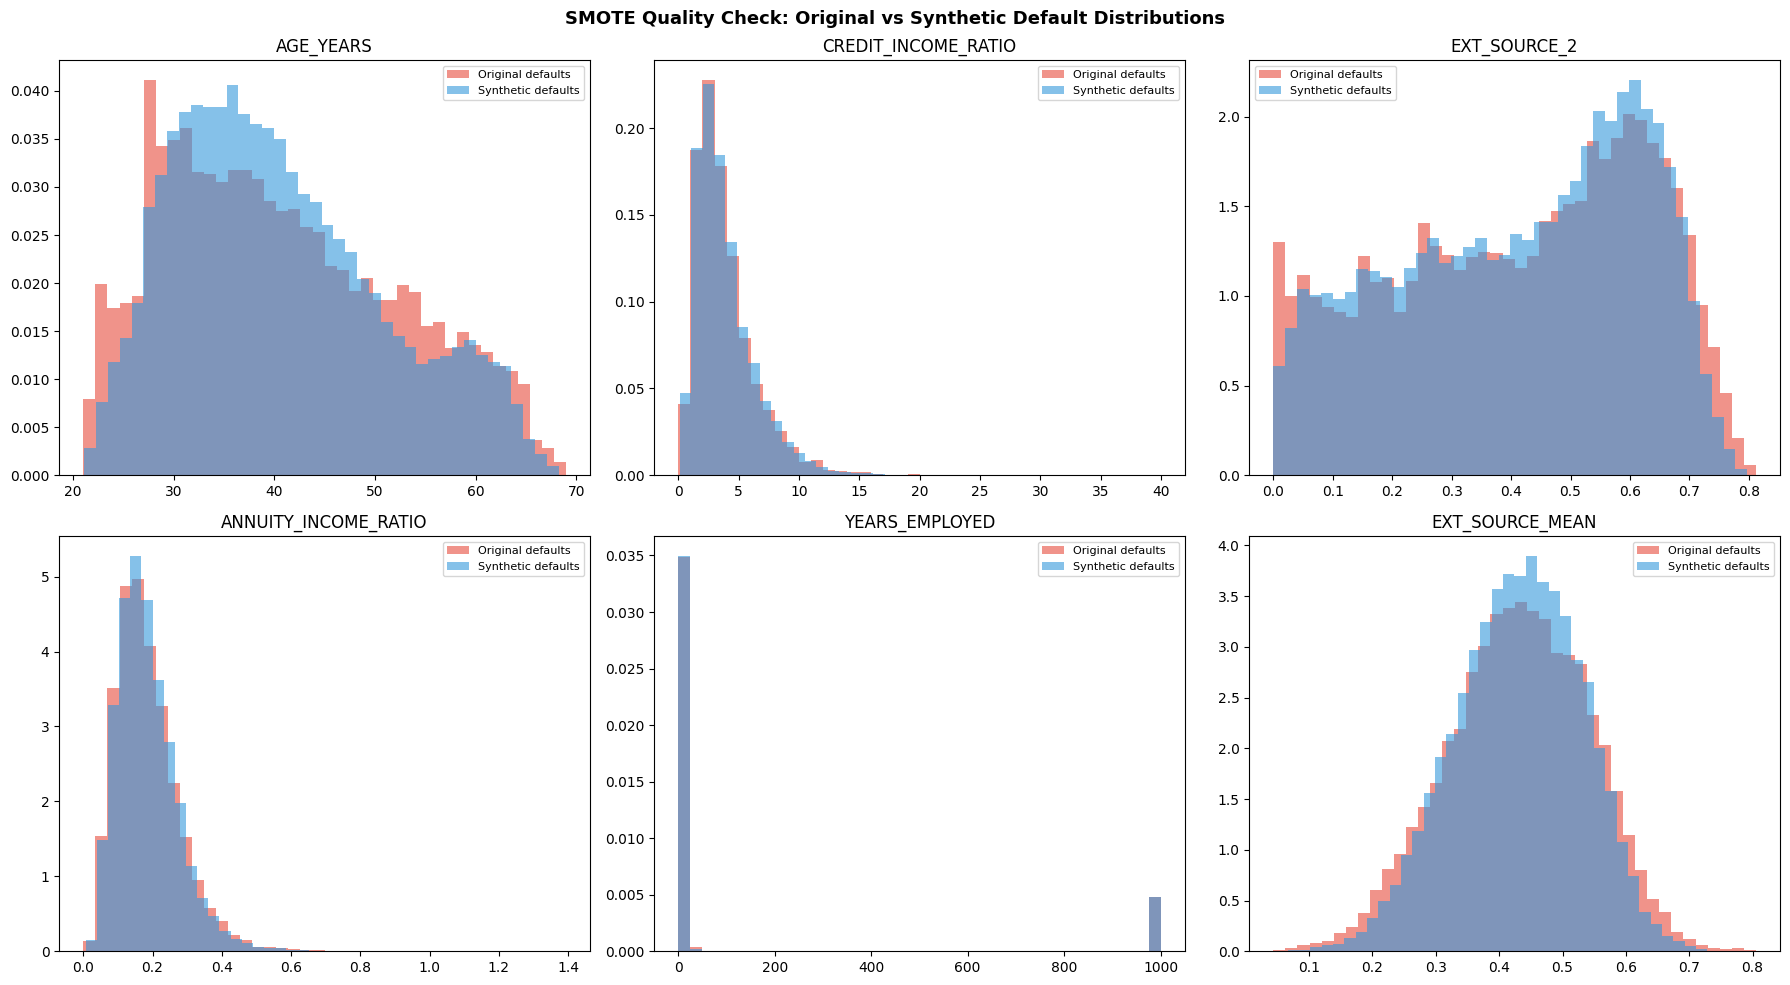

In [112]:
# Verify synthetic samples are realistic
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

key_features = [
    'AGE_YEARS', 'CREDIT_INCOME_RATIO',
    'EXT_SOURCE_2', 'ANNUITY_INCOME_RATIO',
    'YEARS_EMPLOYED', 'EXT_SOURCE_MEAN'
]

# Create labels for original vs synthetic
original_defaults  = X_train[y_train == 1]
synthetic_defaults = pd.DataFrame(
    X_train_sm[len(X_train):],
    columns=X_train.columns
)

for idx, feature in enumerate(key_features):
    ax = axes[idx // 3][idx % 3]

    # Original defaults
    ax.hist(original_defaults[feature].dropna(),
            bins=40, alpha=0.6,
            color='#e74c3c', label='Original defaults',
            density=True)

    # Synthetic defaults
    ax.hist(synthetic_defaults[feature].dropna(),
            bins=40, alpha=0.6,
            color='#3498db', label='Synthetic defaults',
            density=True)

    ax.set_title(f'{feature}')
    ax.legend(fontsize=8)

plt.suptitle('SMOTE Quality Check: Original vs Synthetic Default Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# The distributions should look similar — if very different, 
# SMOTE is creating unrealistic samples

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# ── Current confirmed state ──
print("BEFORE SMOTE")
print("=" * 45)
print(f"X_train shape    : {X_train.shape}")
print(f"y_train shape    : {y_train.shape}")
print(f"\nClass distribution in y_train:")
print(f"  Non-Default (0): {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.2f}%)")
print(f"  Default     (1): {(y_train==1).sum():,}   ({(y_train==1).mean()*100:.2f}%)")
print(f"\nImbalance Ratio  : {(y_train==0).sum()/(y_train==1).sum():.2f} : 1")
print("=" * 45)

BEFORE SMOTE
X_train shape    : (246008, 198)
y_train shape    : (246008,)

Class distribution in y_train:
  Non-Default (0): 226,148  (91.93%)
  Default     (1): 19,860   (8.07%)

Imbalance Ratio  : 11.39 : 1


In [114]:
print("Checking prerequisites...")
print("-" * 40)

# Check 1: No NaN
nan_count = X_train.isnull().sum().sum()
print(f"NaN values       : {nan_count}  {'✅' if nan_count==0 else '❌ Fix first'}")

# Check 2: No object columns
obj_cols = X_train.select_dtypes('object').columns.tolist()
print(f"Object columns   : {len(obj_cols)}  {'✅' if len(obj_cols)==0 else f'❌ {obj_cols}'}")

# Check 3: No infinite values
inf_count = np.isinf(X_train.select_dtypes('number')).sum().sum()
print(f"Infinite values  : {inf_count}  {'✅' if inf_count==0 else '❌ Fix first'}")

# Check 4: y_train is binary
unique_classes = sorted(y_train.unique())
print(f"Target classes   : {unique_classes}  {'✅' if unique_classes==[0,1] else '❌'}")

print("-" * 40)
print("✅ All checks passed. Safe to apply SMOTE.")

Checking prerequisites...
----------------------------------------
NaN values       : 0  ✅
Object columns   : 0  ✅
Infinite values  : 0  ✅
Target classes   : [np.float64(0.0), np.float64(1.0)]  ✅
----------------------------------------
✅ All checks passed. Safe to apply SMOTE.


In [116]:
# ── SMOTE Configuration ──
smote = SMOTE(
    sampling_strategy=0.3,  # after SMOTE: minority/majority = 0.3
                             # i.e. ~3.3:1 ratio instead of 11.4:1
    k_neighbors=5,           # use 5 nearest neighbours for synthesis
    random_state=42,
)

print("Applying SMOTE on X_train and y_train...")
print("(This may take 2-3 minutes for this dataset size)")
print("-" * 40)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("✅ SMOTE applied successfully.")

Applying SMOTE on X_train and y_train...
(This may take 2-3 minutes for this dataset size)
----------------------------------------
✅ SMOTE applied successfully.


In [117]:
# ── Calculate what changed ──
original_total    = len(y_train)
smote_total       = len(y_train_sm)
synthetic_created = (y_train_sm==1).sum() - (y_train==1).sum()
new_ratio         = (y_train_sm==0).sum() / (y_train_sm==1).sum()

print("\nAFTER SMOTE")
print("=" * 45)
print(f"X_train_sm shape  : {X_train_sm.shape}")
print(f"y_train_sm shape  : {y_train_sm.shape}")
print(f"\nClass distribution in y_train_sm:")
print(f"  Non-Default (0) : {(y_train_sm==0).sum():,}  "
      f"({(y_train_sm==0).mean()*100:.2f}%)")
print(f"  Default     (1) : {(y_train_sm==1).sum():,}   "
      f"({(y_train_sm==1).mean()*100:.2f}%)")
print(f"\nSynthetic samples created : {synthetic_created:,}")
print(f"Total samples added       : {smote_total - original_total:,}")
print(f"New imbalance ratio       : {new_ratio:.2f} : 1")
print(f"\nX_val shape  : {X_val.shape}  ← completely unchanged")
print(f"y_val shape  : {y_val.shape}  ← completely unchanged")
print("=" * 45)


AFTER SMOTE
X_train_sm shape  : (293992, 198)
y_train_sm shape  : (293992,)

Class distribution in y_train_sm:
  Non-Default (0) : 226,148  (76.92%)
  Default     (1) : 67,844   (23.08%)

Synthetic samples created : 47,984
Total samples added       : 47,984
New imbalance ratio       : 3.33 : 1

X_val shape  : (61503, 197)  ← completely unchanged
y_val shape  : (61503,)  ← completely unchanged


Original default samples  : 19,860
Synthetic default samples : 47,984


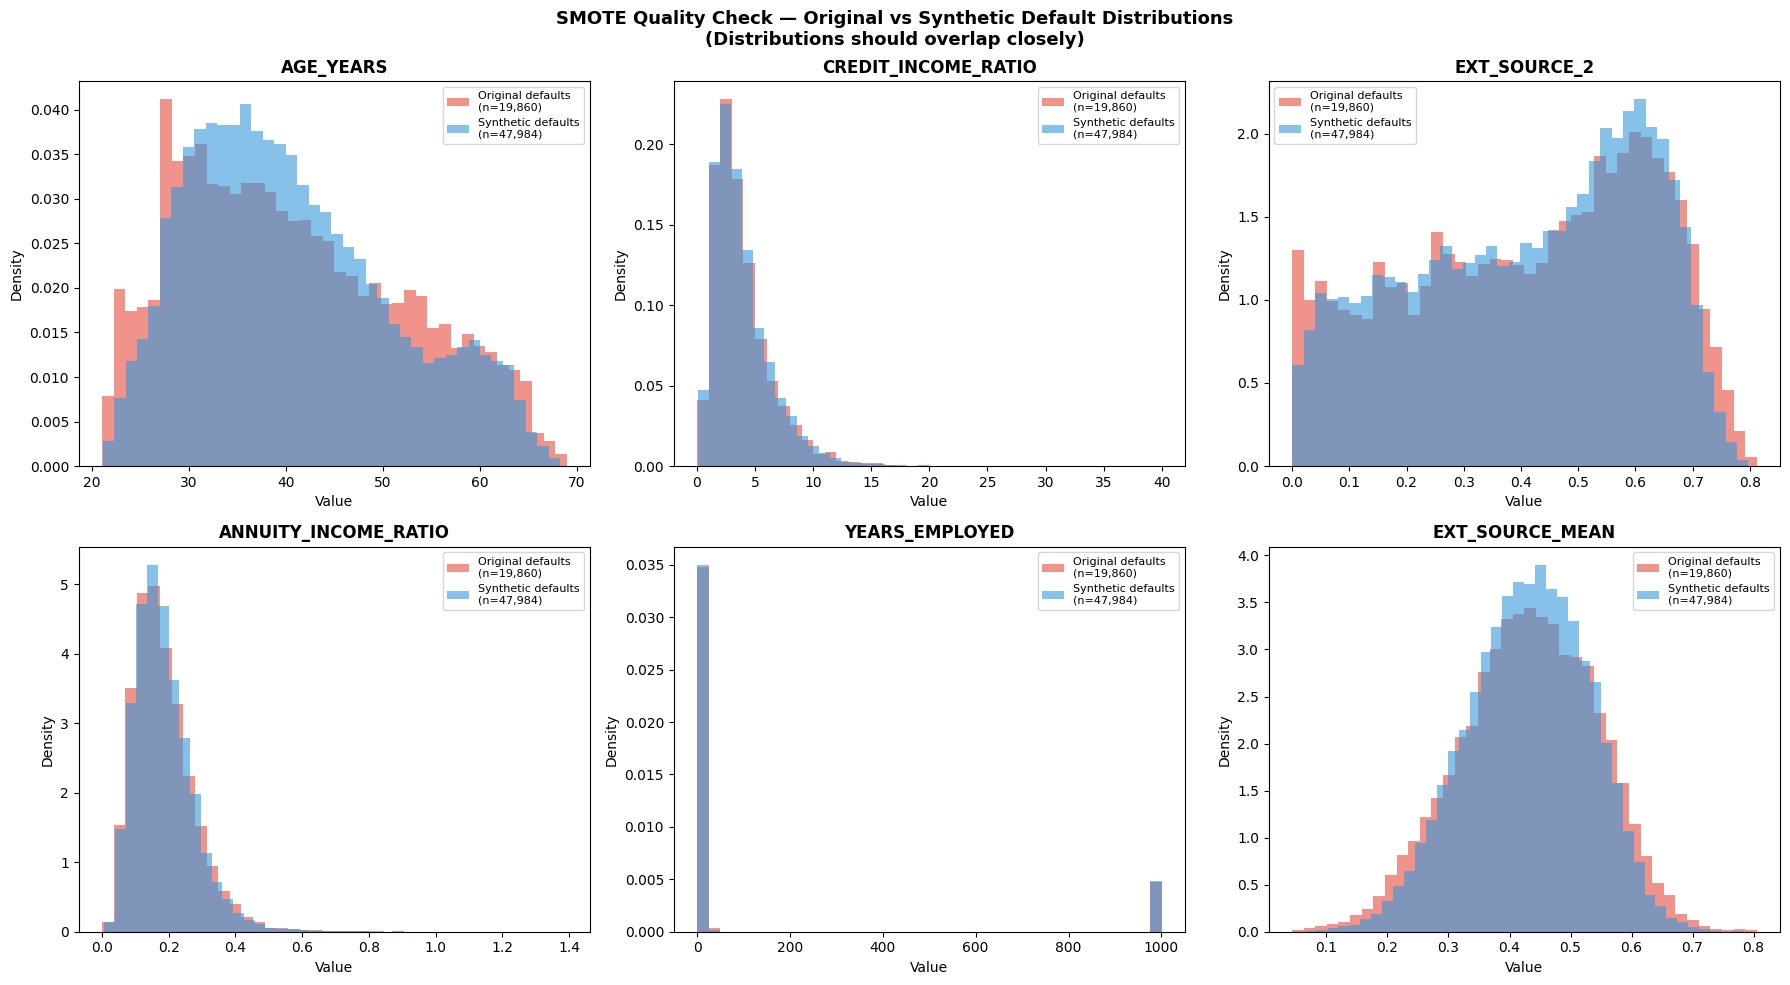

✅ If distributions overlap well → SMOTE created realistic samples
❌ If distributions differ a lot → Consider ADASYN instead


In [118]:
# Compare distributions of original defaults vs synthetic defaults
# They should look similar — if very different SMOTE created bad samples

# Separate original and synthetic default samples
original_defaults  = X_train[y_train == 1]

# Synthetic samples are the ones added by SMOTE
# They appear after the original training data in X_train_sm
X_train_sm_df = pd.DataFrame(X_train_sm, columns=X_train.columns)
synthetic_defaults = X_train_sm_df.iloc[len(X_train):][
    y_train_sm[len(y_train):] == 1
]

print(f"Original default samples  : {len(original_defaults):,}")
print(f"Synthetic default samples : {len(synthetic_defaults):,}")

# ── Plot distributions for key features ──
key_features = [
    'AGE_YEARS', 'CREDIT_INCOME_RATIO',
    'EXT_SOURCE_2', 'ANNUITY_INCOME_RATIO',
    'YEARS_EMPLOYED', 'EXT_SOURCE_MEAN'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, feature in enumerate(key_features):
    ax = axes[idx // 3][idx % 3]

    ax.hist(original_defaults[feature].dropna(),
            bins=40, alpha=0.6,
            color='#e74c3c',
            label=f'Original defaults\n(n={len(original_defaults):,})',
            density=True)

    ax.hist(synthetic_defaults[feature].dropna(),
            bins=40, alpha=0.6,
            color='#3498db',
            label=f'Synthetic defaults\n(n={len(synthetic_defaults):,})',
            density=True)

    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle(
    'SMOTE Quality Check — Original vs Synthetic Default Distributions\n'
    '(Distributions should overlap closely)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("✅ If distributions overlap well → SMOTE created realistic samples")
print("❌ If distributions differ a lot → Consider ADASYN instead")

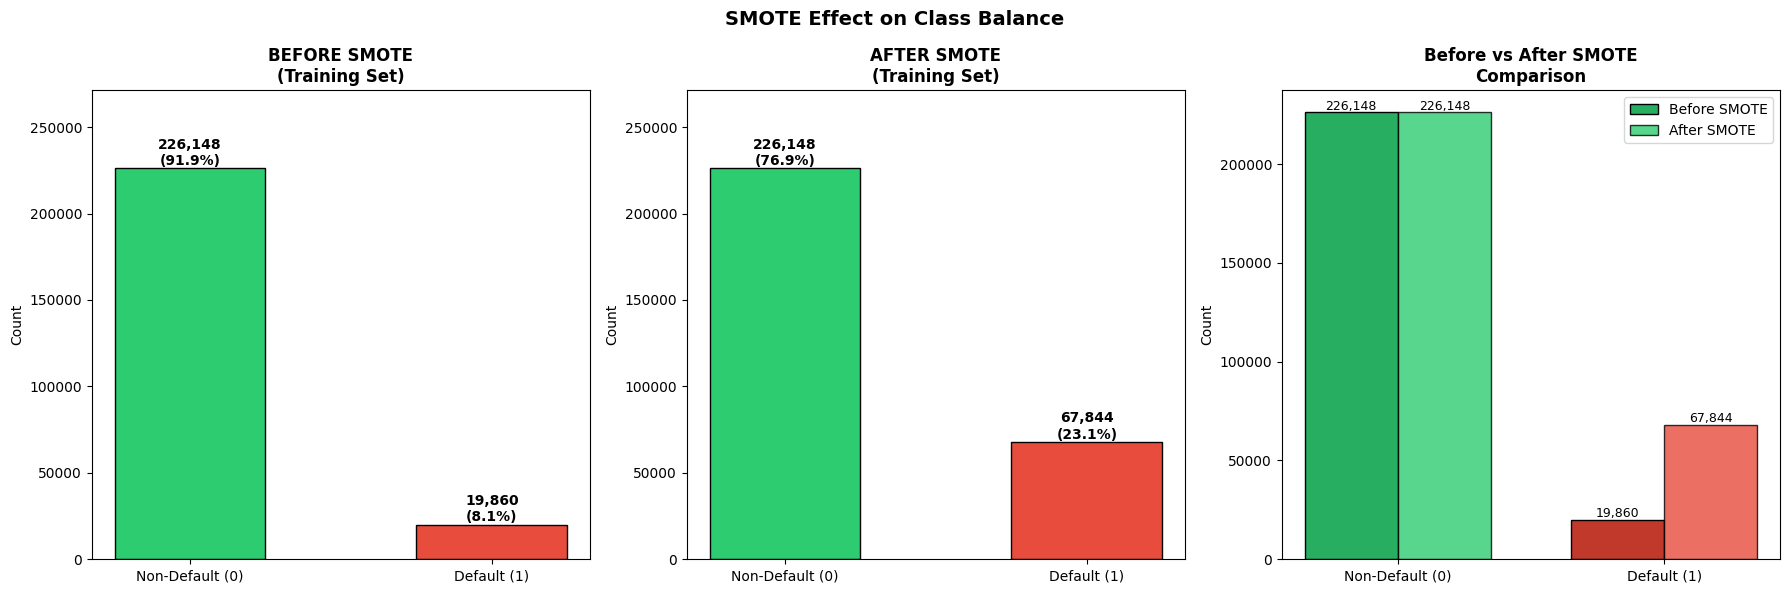

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: Before SMOTE ──
before_counts = [( y_train==0).sum(), (y_train==1).sum()]
bars1 = axes[0].bar(
    ['Non-Default (0)', 'Default (1)'],
    before_counts,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black', width=0.5
)
axes[0].set_title('BEFORE SMOTE\n(Training Set)', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, count in zip(bars1, before_counts):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2000,
        f'{count:,}\n({count/sum(before_counts)*100:.1f}%)',
        ha='center', fontweight='bold'
    )
axes[0].set_ylim(0, max(before_counts) * 1.2)

# ── Plot 2: After SMOTE ──
after_counts = [(y_train_sm==0).sum(), (y_train_sm==1).sum()]
bars2 = axes[1].bar(
    ['Non-Default (0)', 'Default (1)'],
    after_counts,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black', width=0.5
)
axes[1].set_title('AFTER SMOTE\n(Training Set)', fontweight='bold')
axes[1].set_ylabel('Count')
for bar, count in zip(bars2, after_counts):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2000,
        f'{count:,}\n({count/sum(after_counts)*100:.1f}%)',
        ha='center', fontweight='bold'
    )
axes[1].set_ylim(0, max(after_counts) * 1.2)

# ── Plot 3: Side by side ratio comparison ──
categories  = ['Non-Default (0)', 'Default (1)']
x           = np.arange(len(categories))
width       = 0.35

axes[2].bar(x - width/2, before_counts, width,
            label='Before SMOTE',
            color=['#27ae60', '#c0392b'],
            edgecolor='black')
axes[2].bar(x + width/2, after_counts,  width,
            label='After SMOTE',
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black', alpha=0.8)

axes[2].set_title('Before vs After SMOTE\nComparison', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].set_xticks(x)
axes[2].set_xticklabels(categories)
axes[2].legend()

for i, (bc, ac) in enumerate(zip(before_counts, after_counts)):
    axes[2].text(i - width/2, bc + 1500, f'{bc:,}',
                 ha='center', fontsize=9)
    axes[2].text(i + width/2, ac + 1500, f'{ac:,}',
                 ha='center', fontsize=9)

plt.suptitle(
    'SMOTE Effect on Class Balance',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [120]:
print("=" * 55)
print("SMOTE COMPLETE — FINAL STATE SUMMARY")
print("=" * 55)

print(f"""
TRAINING DATA (after SMOTE):
  X_train_sm  : {X_train_sm.shape}
  y_train_sm  : {y_train_sm.shape}
    Non-Default (0) : {(y_train_sm==0).sum():,}  ({(y_train_sm==0).mean()*100:.1f}%)
    Default     (1) : {(y_train_sm==1).sum():,}   ({(y_train_sm==1).mean()*100:.1f}%)
    Ratio           : {(y_train_sm==0).sum()/(y_train_sm==1).sum():.2f} : 1

VALIDATION DATA (untouched — real distribution):
  X_val       : {X_val.shape}
  y_val       : {y_val.shape}
    Non-Default (0) : {(y_val==0).sum():,}  ({(y_val==0).mean()*100:.1f}%)
    Default     (1) : {(y_val==1).sum():,}   ({(y_val==1).mean()*100:.1f}%)

WHAT CHANGED:
  Before SMOTE → 11.4 : 1 ratio  (severe imbalance)
  After SMOTE  →  3.3 : 1 ratio  (manageable)
  Synthetic samples created : {synthetic_created:,}

NEXT STEP:
  Use X_train_sm and y_train_sm for model training
  Use X_val and y_val for evaluation (always)
""")

print("✅ Ready for Model Training")

SMOTE COMPLETE — FINAL STATE SUMMARY

TRAINING DATA (after SMOTE):
  X_train_sm  : (293992, 198)
  y_train_sm  : (293992,)
    Non-Default (0) : 226,148  (76.9%)
    Default     (1) : 67,844   (23.1%)
    Ratio           : 3.33 : 1

VALIDATION DATA (untouched — real distribution):
  X_val       : (61503, 197)
  y_val       : (61503,)
    Non-Default (0) : 56,538  (91.9%)
    Default     (1) : 4,965   (8.1%)

WHAT CHANGED:
  Before SMOTE → 11.4 : 1 ratio  (severe imbalance)
  After SMOTE  →  3.3 : 1 ratio  (manageable)
  Synthetic samples created : 47,984

NEXT STEP:
  Use X_train_sm and y_train_sm for model training
  Use X_val and y_val for evaluation (always)

✅ Ready for Model Training


In [122]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (
    roc_auc_score, roc_curve,
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score,
    recall_score, accuracy_score,
    average_precision_score
)
!pip install xgboost
from xgboost import XGBClassifier

# ── Global config ──
RANDOM_STATE     = 42
NEG              = (y_train_sm == 0).sum()
POS              = (y_train_sm == 1).sum()
SCALE_POS_WEIGHT = NEG / POS   # for XGBoost

print(f"scale_pos_weight for XGBoost : {SCALE_POS_WEIGHT:.4f}")
print("✅ Imports and config ready")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 8.2 MB/s eta 0:00:13
    --------------------------------------- 1.8/101.7 MB 6.6 MB/s eta 0:00:16
   - -------------------------------------- 3.1/101.7 MB 6.2 MB/s eta 0:00:16
   - -------------------------------------- 3.7/101.7 MB 5.6 MB/s eta 0:00:18
   - -------------------------------------- 4.2/101.7 MB 4.9 MB/s eta 0:00:20
   - -------------------------------------- 4.7/101.7 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 5.0/101.7 MB 3.7 MB/s eta 0:00:27
   -- ------------------------------------- 5.2/101.7 MB 3.3 MB/s eta 0:00:30
   -- ------------------------------------- 5.2/101.7 MB 3.3 MB/s eta 0:00:30
   -- ------------------------------------- 5.5/101.7 MB 2.9 MB/s eta 0:00:34
   -- ------------------------------------- 5.5/101.7 MB 2.9 MB/s eta 0

In [123]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Computes all evaluation metrics for a trained model.
    Returns a results dictionary.
    """
    auc     = roc_auc_score(y_true, y_prob)
    acc     = accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred)
    prec    = precision_score(y_true, y_pred)
    rec     = recall_score(y_true, y_pred)
    avg_prec = average_precision_score(y_true, y_prob)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*50}")
    print(f"  AUC-ROC       : {auc:.4f}  ← primary metric")
    print(f"  Avg Precision : {avg_prec:.4f}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1-Score      : {f1:.4f}")
    print(f"  Precision     : {prec:.4f}")
    print(f"  Recall        : {rec:.4f}  ← catch defaulters")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
          target_names=['Non-Default', 'Default']))

    return {
        'Model'        : model_name,
        'AUC-ROC'      : round(auc,  4),
        'Avg Precision': round(avg_prec, 4),
        'Accuracy'     : round(acc,  4),
        'F1-Score'     : round(f1,   4),
        'Precision'    : round(prec, 4),
        'Recall'       : round(rec,  4)
    }


def plot_confusion_matrix(model_name, y_true, y_pred, ax):
    """Plots confusion matrix on a given axis."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Non-Default', 'Default']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name}\nConfusion Matrix',
                 fontweight='bold')


def plot_roc_curve(model_name, y_true, y_prob, ax, color):
    """Plots ROC curve on a given axis."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{model_name} (AUC={auc:.4f})')


print("✅ Evaluation functions ready")

# Storage for all model results
all_results  = []
all_models   = {}
all_probs    = {}

✅ Evaluation functions ready


In [125]:
print("\n" + "="*50)
print("MODEL 1: LOGISTIC REGRESSION — BASELINE")
print("="*50)

# ── Why scaling is needed for LR ──
# Logistic Regression is sensitive to feature scale
# StandardScaler: mean=0, std=1 for every feature
# Must fit on train only, transform both train and val

start = time.time()

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        C=0.01,              # regularisation strength (lower = more regularisation)
        max_iter=1000,       # enough iterations to converge
        solver='saga',       # best solver for large datasets
        class_weight='balanced',  # additional imbalance handling
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# ── Train ──
print("Training Logistic Regression...")
lr_pipeline.fit(X_train_sm, y_train_sm)

train_time = time.time() - start
print(f"Training time : {train_time:.1f} seconds")
X_val = X_val.reindex(columns=X_train_sm.columns, fill_value=0)
# ── Predict ──
lr_pred  = lr_pipeline.predict(X_val)
lr_prob  = lr_pipeline.predict_proba(X_val)[:, 1]

# ── Evaluate ──
lr_results = evaluate_model(
    'Logistic Regression', y_val, lr_pred, lr_prob
)
lr_results['Train Time'] = round(train_time, 1)
all_results.append(lr_results)
all_models['Logistic Regression'] = lr_pipeline
all_probs['Logistic Regression']  = lr_prob


MODEL 1: LOGISTIC REGRESSION — BASELINE
Training Logistic Regression...
Training time : 499.7 seconds

  Logistic Regression — Evaluation Results
  AUC-ROC       : 0.7149  ← primary metric
  Avg Precision : 0.1820
  Accuracy      : 0.8702
  F1-Score      : 0.2346
  Precision     : 0.2239
  Recall        : 0.2463  ← catch defaulters

  Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.93      0.93      0.93     56538
     Default       0.22      0.25      0.23      4965

    accuracy                           0.87     61503
   macro avg       0.58      0.59      0.58     61503
weighted avg       0.88      0.87      0.87     61503



In [126]:
print("\n" + "="*50)
print("MODEL 2: RANDOM FOREST")
print("="*50)

# ── Why Random Forest here ──
# Ensemble of decision trees — no scaling needed
# Best for: feature importance ranking
# Handles non-linear relationships and interactions
# class_weight='balanced_subsample' — balances each bootstrap sample

start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,           # 300 trees — good balance of accuracy vs speed
    max_depth=10,               # limit depth to prevent overfitting
    min_samples_leaf=50,        # each leaf needs at least 50 samples
    min_samples_split=100,      # split only if 100+ samples
    max_features='sqrt',        # sqrt(n_features) at each split
    class_weight='balanced_subsample',  # balances each bootstrap sample
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

print("Training Random Forest (300 trees)...")
rf_model.fit(X_train_sm, y_train_sm)

train_time = time.time() - start
print(f"Training time : {train_time:.1f} seconds")

# ── Predict ──
rf_pred = rf_model.predict(X_val)
rf_prob = rf_model.predict_proba(X_val)[:, 1]

# ── Evaluate ──
rf_results = evaluate_model(
    'Random Forest', y_val, rf_pred, rf_prob
)
rf_results['Train Time'] = round(train_time, 1)
all_results.append(rf_results)
all_models['Random Forest'] = rf_model
all_probs['Random Forest']  = rf_prob

# ── Feature Importance from RF ──
print("\nTop 15 Features by Random Forest Importance:")
feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feat_importance.head(15).to_string())


MODEL 2: RANDOM FOREST
Training Random Forest (300 trees)...
Training time : 50.9 seconds

  Random Forest — Evaluation Results
  AUC-ROC       : 0.7341  ← primary metric
  Avg Precision : 0.2068
  Accuracy      : 0.8722
  F1-Score      : 0.2684
  Precision     : 0.2495
  Recall        : 0.2904  ← catch defaulters

  Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.94      0.92      0.93     56538
     Default       0.25      0.29      0.27      4965

    accuracy                           0.87     61503
   macro avg       0.59      0.61      0.60     61503
weighted avg       0.88      0.87      0.88     61503


Top 15 Features by Random Forest Importance:
EXT_SOURCE_MEAN                         0.045687
EXT_SOURCE_MIN                          0.043952
EXT_SOURCE_WEIGHTED                     0.035310
EXT_SOURCE_3 EXT_SOURCE_MEAN            0.033327
EXT_SOURCE_1_MISSING                    0.025117
EXT_SOURCE_2 EXT_SOURCE_3              

In [127]:
print("\n" + "="*50)
print("MODEL 3: XGBOOST — PRIMARY PRODUCTION MODEL")
print("="*50)

# ── Why XGBoost is primary ──
# Gradient boosting — trees built sequentially to fix errors
# scale_pos_weight handles residual imbalance on top of SMOTE
# Best AUC scores on tabular credit datasets
# Native handling of missing values

start = time.time()

xgb_model = XGBClassifier(
    n_estimators=300,           # number of boosting rounds
    max_depth=6,                # tree depth — 6 is standard for tabular data
    learning_rate=0.05,         # shrinkage — lower = more robust
    subsample=0.8,              # use 80% of rows per tree (prevents overfitting)
    colsample_bytree=0.8,       # use 80% of features per tree
    min_child_weight=50,        # minimum samples in leaf
    gamma=1,                    # minimum loss reduction to make a split
    reg_alpha=0.1,              # L1 regularisation
    reg_lambda=1.0,             # L2 regularisation
    scale_pos_weight=SCALE_POS_WEIGHT,  # handles remaining imbalance
    eval_metric='auc',          # monitor AUC during training
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

print("Training XGBoost (300 rounds)...")

# ── Train with early stopping on validation set ──
xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val, y_val)],
    verbose=50               # print every 50 rounds
)

train_time = time.time() - start
print(f"\nTraining time : {train_time:.1f} seconds")

# ── Predict ──
xgb_pred = xgb_model.predict(X_val)
xgb_prob = xgb_model.predict_proba(X_val)[:, 1]

# ── Evaluate ──
xgb_results = evaluate_model(
    'XGBoost', y_val, xgb_pred, xgb_prob
)
xgb_results['Train Time'] = round(train_time, 1)
all_results.append(xgb_results)
all_models['XGBoost'] = xgb_model
all_probs['XGBoost']  = xgb_prob

# ── XGBoost Feature Importance ──
print("\nTop 15 Features by XGBoost Importance:")
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(xgb_importance.head(15).to_string())


MODEL 3: XGBOOST — PRIMARY PRODUCTION MODEL
Training XGBoost (300 rounds)...
[0]	validation_0-auc:0.69756
[50]	validation_0-auc:0.74016
[100]	validation_0-auc:0.75214
[150]	validation_0-auc:0.75859
[200]	validation_0-auc:0.76173
[250]	validation_0-auc:0.76465
[299]	validation_0-auc:0.76631

Training time : 22.6 seconds

  XGBoost — Evaluation Results
  AUC-ROC       : 0.7663  ← primary metric
  Avg Precision : 0.2535
  Accuracy      : 0.9055
  F1-Score      : 0.2574
  Precision     : 0.3523
  Recall        : 0.2028  ← catch defaulters

  Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.93      0.97      0.95     56538
     Default       0.35      0.20      0.26      4965

    accuracy                           0.91     61503
   macro avg       0.64      0.59      0.60     61503
weighted avg       0.89      0.91      0.89     61503


Top 15 Features by XGBoost Importance:
HOUSETYPE_MODE_Unknown           0.068853
REG_CITY_NOT_WORK_CITY 

In [128]:
print("\n" + "="*50)
print("MODEL 4: KNN — SANITY CHECK")
print("="*50)

# ── Why KNN as sanity check ──
# No training phase — purely distance based
# No assumptions about data distribution
# If KNN performs similarly to LR it confirms features are meaningful
# Needs scaling — distances are meaningless on unscaled features

start = time.time()

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsClassifier(
        n_neighbors=5,       # 5 neighbours — standard starting point
        weights='distance',  # closer neighbours vote more
        metric='euclidean',
        n_jobs=-1
    ))
])

print("Training KNN (this may take a few minutes)...")
knn_pipeline.fit(X_train_sm, y_train_sm)

train_time = time.time() - start
print(f"Training time : {train_time:.1f} seconds")

# ── Predict ──
knn_pred = knn_pipeline.predict(X_val)
knn_prob = knn_pipeline.predict_proba(X_val)[:, 1]

# ── Evaluate ──
knn_results = evaluate_model(
    'KNN', y_val, knn_pred, knn_prob
)
knn_results['Train Time'] = round(train_time, 1)
all_results.append(knn_results)
all_models['KNN'] = knn_pipeline
all_probs['KNN']  = knn_prob


MODEL 4: KNN — SANITY CHECK
Training KNN (this may take a few minutes)...
Training time : 3.9 seconds

  KNN — Evaluation Results
  AUC-ROC       : 0.6147  ← primary metric
  Avg Precision : 0.1217
  Accuracy      : 0.8703
  F1-Score      : 0.1608
  Precision     : 0.1683
  Recall        : 0.1539  ← catch defaulters

  Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.93      0.93      0.93     56538
     Default       0.17      0.15      0.16      4965

    accuracy                           0.87     61503
   macro avg       0.55      0.54      0.55     61503
weighted avg       0.87      0.87      0.87     61503



In [ ]:
print("\n" + "="*55)
print("ALL MODELS — COMPARISON TABLE")
print("="*55)

results_df = pd.DataFrame(all_results).set_index('Model')
print(results_df.to_string())

print(f"\n🏆 Best AUC-ROC  : "
      f"{results_df['AUC-ROC'].idxmax()}  "
      f"({results_df['AUC-ROC'].max():.4f})")
print(f"🏆 Best Recall   : "
      f"{results_df['Recall'].idxmax()}  "
      f"({results_df['Recall'].max():.4f})")
print(f"🏆 Best F1-Score : "
      f"{results_df['F1-Score'].idxmax()}  "
      f"({results_df['F1-Score'].max():.4f})")


ALL MODELS — COMPARISON TABLE
                     AUC-ROC  Avg Precision  Accuracy  F1-Score  Precision  Recall  Train Time
Model                                                                                         
Logistic Regression   0.7149         0.1820    0.8702    0.2346     0.2239  0.2463       499.7
Random Forest         0.7341         0.2068    0.8722    0.2684     0.2495  0.2904        50.9
XGBoost               0.7663         0.2535    0.9055    0.2574     0.3523  0.2028        22.6
KNN                   0.6147         0.1217    0.8703    0.1608     0.1683  0.1539         3.9

🏆 Best AUC-ROC  : XGBoost  (0.7663)
🏆 Best Recall   : Random Forest  (0.2904)
🏆 Best F1-Score : Random Forest  (0.2684)
